Covid 19 Dataset
================

Research Question:

Can we determine the effect of public health measures (represented in this data set by the variables: government_response_index, stringency_index, containment_health_index, and economic_support_index, described below) on the course of the pandemic by comparing time series data tracking the pandemic in geographically similar areas with different public health responses? 


Welcome to the COVID 19 Dataset. This data set is accessible via the COVID19 R package or the covid19dh python package. In this notebook we use the R package, but their interfaces are largely the same.

The paper associated witht his package describes the data set like this:

> At the time of writing, the dataset includes:
• standard COVID-19 variables: total population, cumulative number of cases, tests,
deaths, recovered, daily number of hospitalized, patients requiring ventilation and in-
tensive therapy.
• policy measures by Oxford COVID-19 Government Response Tracker (Hale et al.,
2020)
• geographic information suited for data visualization and for interfacing with external
databases (e.g. weather information, geo-located tweets).
• external identifiers allowing to extend the dataset with World Bank Open Data, Google
mobility reports, and Apple mobility reports. Governmental identifiers are provided to
further extend the dataset with local, fine-grained statistics.
The data are available at different levels of granularity: 1) administrative area of top-level,
usually countries; 2) states, regions, cantons; 3) cities, municipalities. Refer to the dataset
documentation for more details and to the [introductory video available at COVID-19 Data
Hub]() for an overview of the project (EDITOR's Note: the video appears to be missing).
>

This data provides spatio-temporal covid data in a conveniently queryable form.

In [4]:
ensure_library <- function(pkg) {
  pkg_name <- deparse(substitute(pkg))
  if (!requireNamespace(pkg_name, quietly = TRUE)) {
    install.packages(pkg_name)
  }
  library(pkg_name, character.only = TRUE)
}
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [8]:
ensure_library(COVID19)
data <- covid19(verbose=F) %>% as_tibble()
cat(sprintf('Column names: %s,\n %d rows', paste0(names(data),collapse=", "), nrow(data)))

Column names: id, date, confirmed, deaths, recovered, tests, vaccines, people_vaccinated, people_fully_vaccinated, hosp, icu, vent, school_closing, workplace_closing, cancel_events, gatherings_restrictions, transport_closing, stay_home_restrictions, internal_movement_restrictions, international_movement_restrictions, information_campaigns, testing_policy, contact_tracing, facial_coverings, vaccination_policy, elderly_people_protection, government_response_index, stringency_index, containment_health_index, economic_support_index, administrative_area_level, administrative_area_level_1, administrative_area_level_2, administrative_area_level_3, latitude, longitude, population, iso_alpha_3, iso_alpha_2, iso_numeric, iso_currency, key_local, key_google_mobility, key_apple_mobility, key_jhu_csse, key_nuts, key_gadm,
 287783 rows

This is a huge amount of data - you may wish to start by considering a subset. This can be done temporally and spatially. The Covid 19 data is organized by administrative level (with some included latitude and longitude) as well as by time. We can restrict our attention to the US and to March 2020 to the end of 2023 like this:


We have invested a lot of time and effort in creating COVID-19 Data
Hub, please cite the following when using it:

  Guidotti, E., Ardia, D., (2020), "COVID-19 Data Hub", Journal of Open
  Source Software 5(51):2376, doi: 10.21105/joss.02376

The implementation details and the latest version of the data are
described in:

  Guidotti, E., (2022), "A worldwide epidemiological database for
  COVID-19 at fine-grained spatial resolution", Sci Data 9(1):112, doi:
  10.1038/s41597-022-01245-1

To print citations in BibTeX format use:
 > print(citation('COVID19'), bibtex=TRUE)

To hide this message use 'verbose = FALSE'.


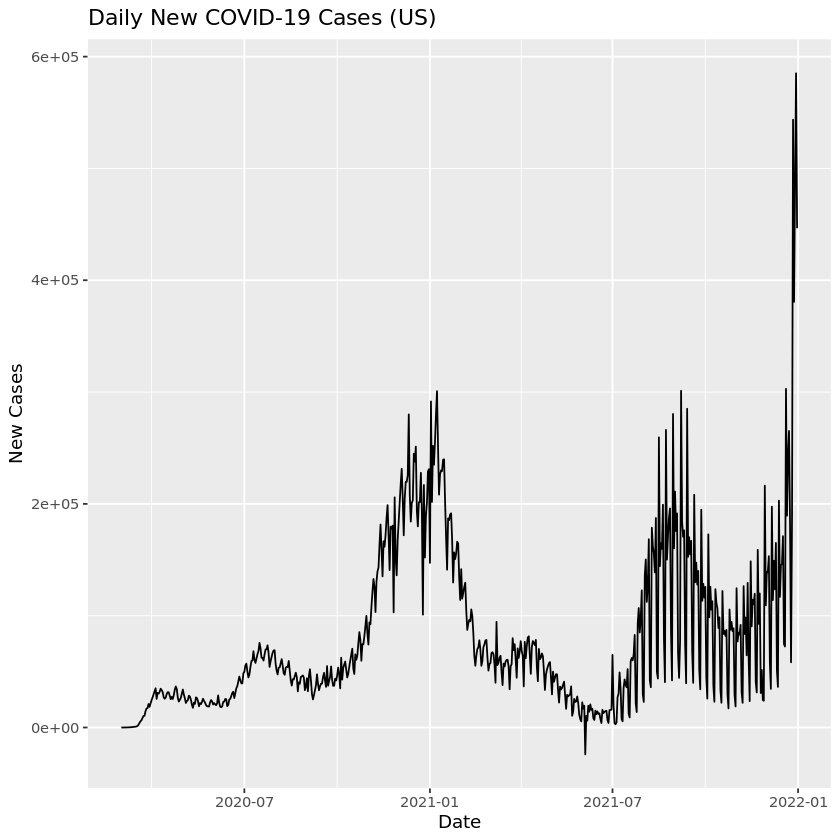

In [9]:
# Line plot of daily new confirmed cases
library(tidyverse)

df_us <- covid19(country = "US", start = "2020-03-01", end = "2021-12-31")
df_us <- df_us %>%
  arrange(date) %>%
  mutate(new_cases = confirmed - lag(confirmed, default = 0))

ggplot(df_us, aes(x = date, y = new_cases)) +
  geom_line() +
  labs(title = "Daily New COVID-19 Cases (US)",
       x = "Date", y = "New Cases")

Note that the covid19 function does not just filter data to the desired rows, it also aggregates as appropriate. So the above data set will not contain data for indivudal US States. If we want to look at that data we can do this:

In [10]:
df_us_states <- covid19(level=2, start = "2020-03-01", end = "2021-12-31") %>% filter(iso_alpha_2=="US")
df_us_states %>% group_by(key_apple_mobility) %>% tally()


We have invested a lot of time and effort in creating COVID-19 Data
Hub, please cite the following when using it:

  Guidotti, E., Ardia, D., (2020), "COVID-19 Data Hub", Journal of Open
  Source Software 5(51):2376, doi: 10.21105/joss.02376

The implementation details and the latest version of the data are
described in:

  Guidotti, E., (2022), "A worldwide epidemiological database for
  COVID-19 at fine-grained spatial resolution", Sci Data 9(1):112, doi:
  10.1038/s41597-022-01245-1

To print citations in BibTeX format use:
 > print(citation('COVID19'), bibtex=TRUE)

To hide this message use 'verbose = FALSE'.


key_apple_mobility,n
<chr>,<int>
Alabama,671
Alaska,671
American Samoa,656
Arizona,671
Arkansas,668
California,671
Colorado,671
Connecticut,671
Delaware,670


Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_line()`).”


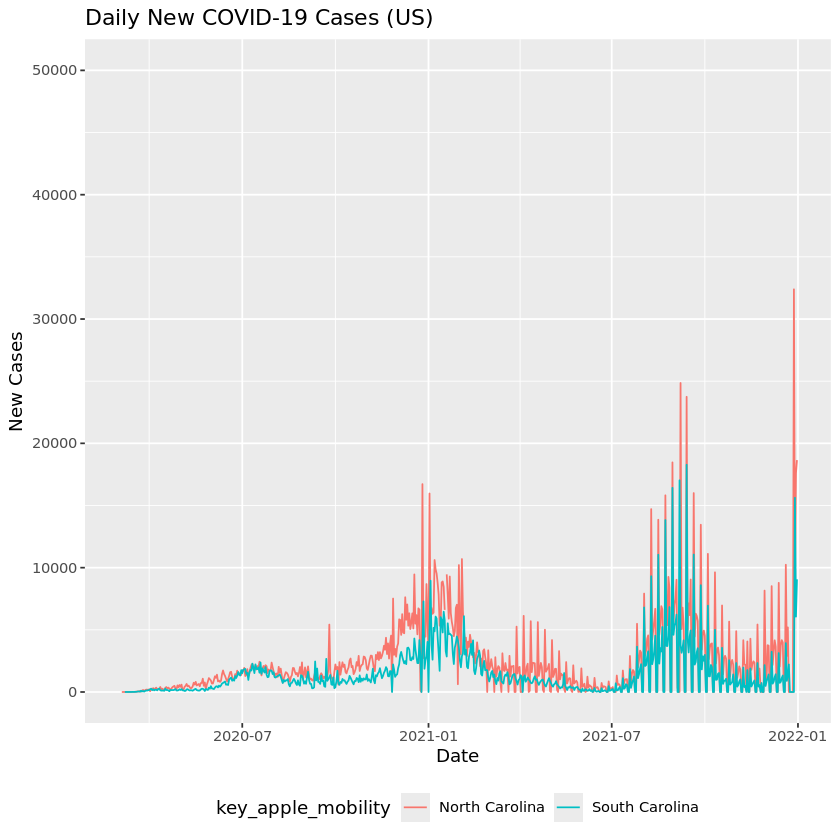

In [11]:
df_us_states <- df_us_states %>%
  group_by(key_apple_mobility) %>% 
  arrange(date) %>%
  mutate(new_cases = confirmed - lag(confirmed, default = 0)) %>%
  ungroup()

ggplot(df_us_states %>% filter(key_apple_mobility %in% c("North Carolina","South Carolina")), aes(x = date, y = new_cases)) +
  geom_line(aes(group=key_apple_mobility, color=key_apple_mobility)) +
  labs(title = "Daily New COVID-19 Cases (US)",
       x = "Date", y = "New Cases") + theme(legend.position = "bottom") + ylim(0,50000)

The data set contains information about policy as well as mortality and morbidity. 


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
“Removed 9 rows containing non-finite outside the scale range (`stat_smooth()`).”
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


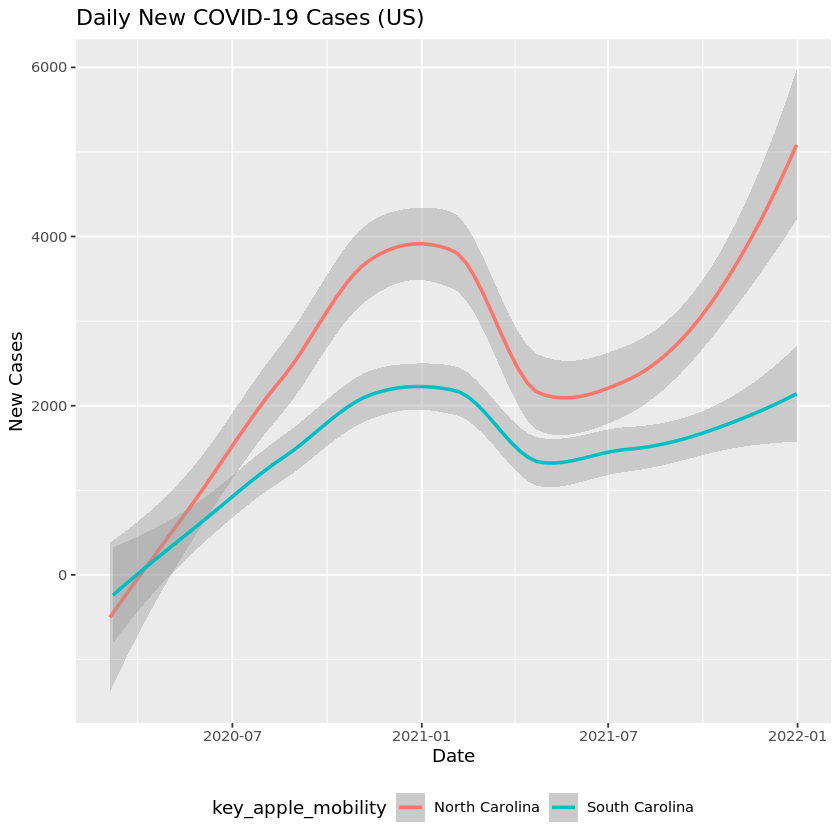

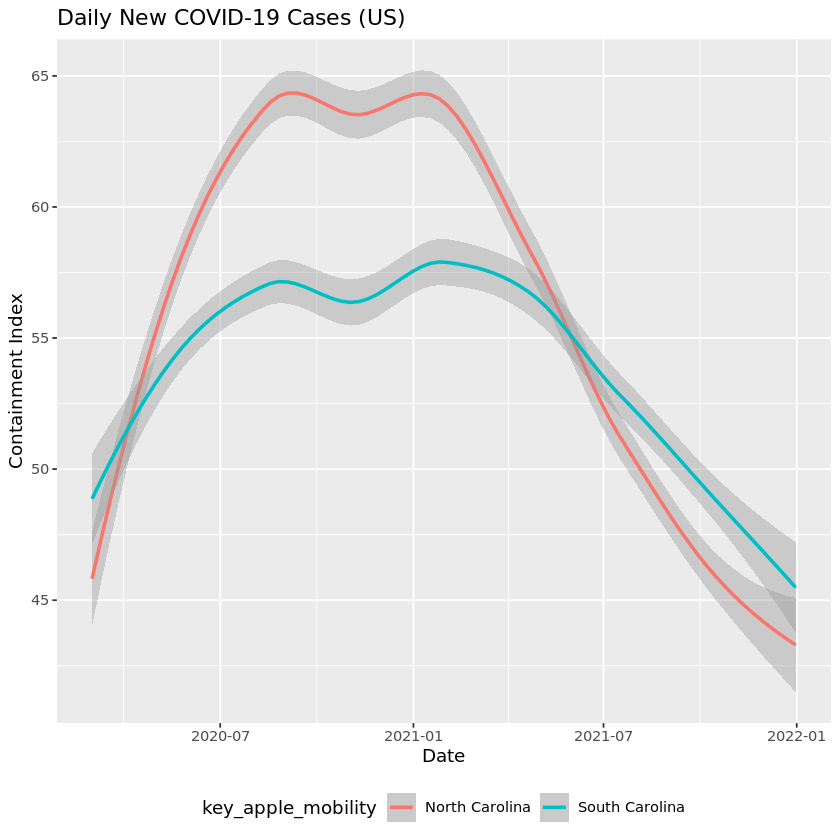

In [13]:
p1 = ggplot(df_us_states %>% filter(key_apple_mobility %in% c("North Carolina","South Carolina")), aes(x=date, y=new_cases)) +
  geom_smooth(aes(group=key_apple_mobility, color=key_apple_mobility)) +
  labs(title = "Daily New COVID-19 Cases (US)",
       x = "Date", y = "New Cases") + theme(legend.position = "bottom")

p2 = ggplot(df_us_states %>% filter(key_apple_mobility %in% c("North Carolina","South Carolina")), aes(x=date, y=containment_health_index)) +
  geom_smooth(aes(group=key_apple_mobility, color=key_apple_mobility)) +
  labs(title = "Daily New COVID-19 Cases (US)",
       x = "Date", y = "Containment Index") + theme(legend.position = "bottom")

p1
p2


Some suggestions: compare the other variables related to interventions:

>government_response_index 	The index records how the response of governments has varied over all indicators in the OxCGRT database, becoming stronger or weaker over the course of the outbreak.
>
>stringency_index 	The index records the strictness of ‘lockdown style’ policies that primarily restrict people’s behaviour.
containment_health_index 	The index combines ‘lockdown’ restrictions and closures with measures such as testing policy and contact tracing, short term investment in healthcare, as well investments in vaccines.
>
>economic_support_index 	The index records measures such as income support and debt relief.
>

What about spatial relations? If we are interested in figuring out the relative effectiveness of interventions, can we find nearby states which had similar trajectories until markedly different interventions?